In [ ]:
# ambiente anaconda
import sys
print(sys.executable) # orange3 ou youtube
import sys
print(sys.version)

/usr/bin/python3
3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


https://colab.research.google.com/

Tarefa: Deep autoencoder na base CIFAR-10
Olá!

Agora que você aprendeu a construir três tipos de autoencoders com o PyTorch aplicados na base de dados MNIST, é hora de trabalhar com uma base de dados mais complexa. Portanto, o objetivo é construir um deep autoencoder utilizando a base de dados cifar10 que possui imagens de aviões, automóveis, pássaros, gatos, veados, cachorros, sapos, cavalos, barcos e caminhões. Siga as seguintes dicas:

As dimensões das imagens são 32 x 32 e possuem 3 canais por serem coloridas. Por isso, a quantidade total de dados de cada imagem é de 3072 (que equivale a quantidade de neurônios na camada de entrada e camada de saída)

Você pode criar duas camadas ocultas para este experimento (para que o tempo de processamento não seja tão alto assim)

Dica para criação das camadas: como temos 3072 entradas, você pode sempre dividir por dois para definir a quantidade de neurônios em cada camada oculta. Por exemplo: 3072 / 2 = 1536, 1536 / 2 = 768 e assim por diante

O objetivo no final é comparar as imagens originais com as imagens decodificadas. Abaixo você pode visualizar o resultado que obtivemos
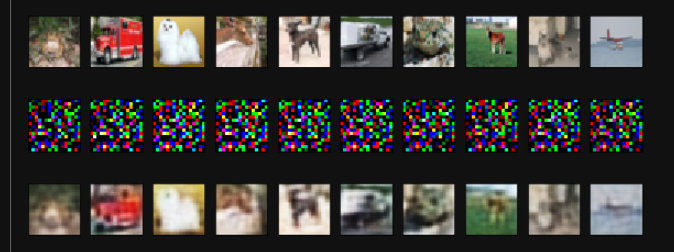




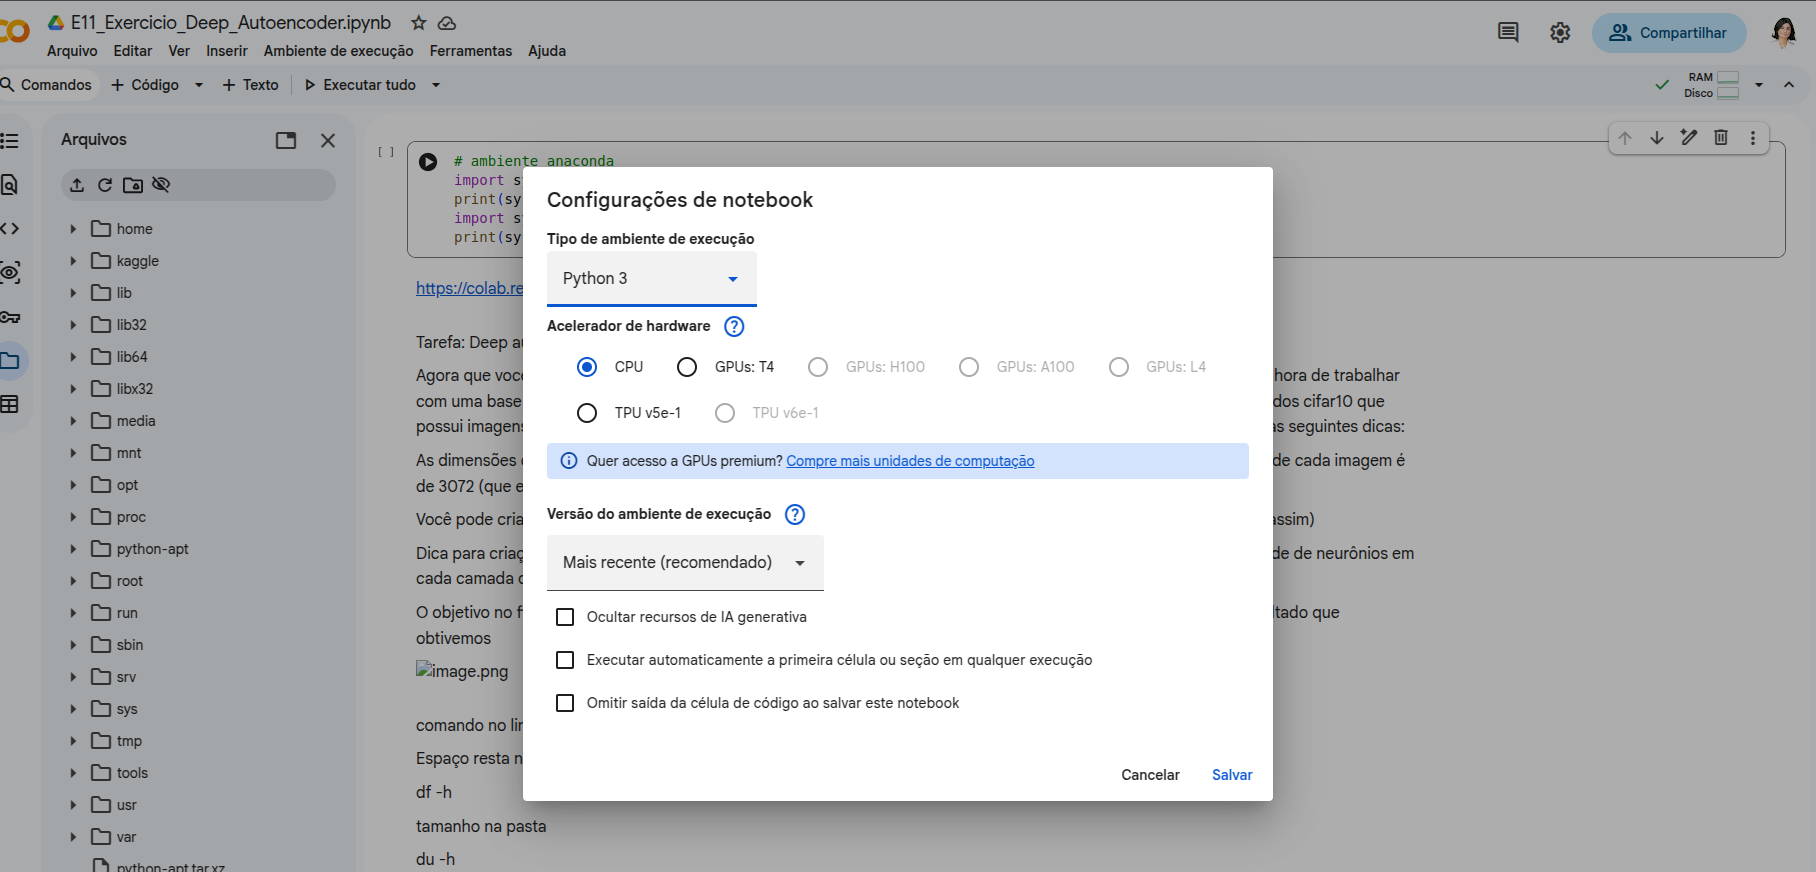

comando no linux

Espaço resta no disco rígido inteiro em GB,

df -h

tamanho na pasta

du -h


# Tarefa: Deep Autoencoders na base de dados CIFAR-10

## Etapa 1: Importação das bibliotecas



In [ ]:
from torchvision import datasets, transforms
import torch
from torch import nn, optim
import matplotlib.pyplot as plt
torch.__version__

'2.10.0+cpu'

In [ ]:
torch.manual_seed(123)

## Etapa 2: Base de dados

In [ ]:
# 1. PREPARANDO O DATASET (A biblioteca de imagens)
# 'CIFAR10-data': Nome da pasta onde as imagens serão salvas.
# train = True: Carrega apenas o conjunto de imagens para TREINO (50.000 imagens).
# download = True: Baixa automaticamente da internet se não estiver na pasta.
# transform = transforms.ToTensor(): A parte mais importante! Converte as imagens
#             (que são arquivos .jpg ou .png) em Tensores do PyTorch.
#             Também escala os pixels de [0, 255] para o intervalo [0, 1].
dataset_train = datasets.CIFAR10('CIFAR10-data', train = True,
                                 download = True,
                                 transform = transforms.ToTensor())

# 2. CONFIGURANDO O LOADER (O "garçom" de dados)
# dataset_train: A fonte de onde ele vai tirar as imagens.
# batch_size = 256: O modelo não estuda uma imagem por vez, mas "pacotes" de 256.
#                   Isso acelera o treino e estabiliza o aprendizado na GPU.
# shuffle = True: Embaralha as imagens a cada época. Isso evita que o modelo
#                 decore a ordem dos exemplos, forçando-o a aprender padrões reais.
loader_train = torch.utils.data.DataLoader(dataset_train,
                                           batch_size = 256,
                                           shuffle = True)

In [ ]:
# 1. PREPARANDO O DATASET DE VALIDAÇÃO (O teste final)
# 'CIFAR10-data': Usa a mesma pasta dos dados de treino.
# train = False: Diz ao PyTorch para baixar/carregar as 10.000 imagens
#                reservadas especificamente para teste/validação.
# download = True: Verifica se os arquivos estão lá; se não, baixa.
# transform: Converte as fotos (RGB 32x32) em Tensores e escala os pixels para [0, 1].
dataset_val = datasets.CIFAR10('CIFAR10-data',
                               train = False,
                               download = True,
                               transform = transforms.ToTensor())

# 2. CONFIGURANDO O LOADER DE VALIDAÇÃO
# dataset_val: A fonte das 10.000 imagens de teste.
# batch_size = 256: Processa as imagens em blocos para ganhar velocidade.
# shuffle = True: Embaralha os dados. Na validação, o shuffle não é obrigatório para
#                 o cálculo do erro, mas ajuda se você for visualizar amostras aleatórias.
loader_val = torch.utils.data.DataLoader(dataset_val,
                                         batch_size = 256,
                                         shuffle = True)

## Etapa 3: Construção do autoencoder

classe define um Autoencoder Linear adaptado para o dataset CIFAR-10. Como as imagens do CIFAR-10 são coloridas (RGB) e possuem tamanho $32 \times 32$, a entrada agora é muito maior ($3 \times 32 \times 32 = 3072$) do que a do MNIST.

In [ ]:
3*32*32


3072

In [ ]:
import math

math.sqrt(3072)

55.42562584220407

In [ ]:
math.sqrt(1536)

39.191835884530846

In [ ]:
3072/2

1536.0

In [ ]:
1536/2

768.0

In [ ]:
class autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # --- ESTRUTURA DO ENCODER (Compressão) ---
        # Camadas do encoder
        # encoder0: Recebe a imagem "achatada" de 3072 pixels (32x32x3 canais)
        # e a reduz pela metade para 1536 neurônios.
        self.encoder0 = nn.Linear(in_features = 3072, out_features = 1536)

        # encoder1: Comprime ainda mais, de 1536 para 768.
        # Este valor (768) é o seu "Espaço Latente" (o resumo da imagem).
        self.encoder1 = nn.Linear(1536, 768)


        # --- ESTRUTURA DO DECODER (Reconstrução) ---
        # Camadas do decoder
        # decoder0: Pega o resumo de 768 e começa a expandir de volta para 1536.
        self.decoder0 = nn.Linear(768, 1536)

        # decoder1: Tenta reconstruir todos os 3072 pixels originais.
        self.decoder1 = nn.Linear(1536, 3072)

        # --- CAMADAS DE ATIVAÇÃO ---
        # Camadas de ativação
        # ReLU: Introduz não-linearidade, ajudando a rede a aprender padrões complexos.
        self.activation0 = nn.ReLU()

        # Sigmoid: Garante que os pixels da imagem final estejam entre 0 e 1,
        # combinando com o formato do ToTensor() que usamos no carregamento.
        self.activation1 = nn.Sigmoid()

    def forward(self, X):
        # --- FLUXO DE EXECUÇÃO ---
        # Estrutura do encoder
        # Passa pelo Encoder para gerar a representação compacta
        X = self.activation0(self.encoder0(X))
        X = self.activation0(self.encoder1(X))

        # Estrutura do decoder
        # Passa pelo Decoder para reconstruir a imagem a partir do resumo
        X = self.activation0(self.decoder0(X))
        X = self.activation1(self.decoder1(X))

        # Retorna a imagem reconstruída (ainda no formato de vetor de 3072)
        return X

In [ ]:
# 1. torch.cuda.is_available():
# Verifica se existe uma GPU da NVIDIA instalada e se os drivers (CUDA) estão funcionando.

# 2. torch.device('cuda'):
# Se a resposta acima for VERDADEIRO, ele define o alvo como a GPU.
# Treinar redes neurais com imagens no CIFAR-10 pode ser até 50x mais rápido na GPU.

# 3. torch.device('cpu'):
# Se NÃO houver GPU (FALSO), ele define o processador (CPU) como o alvo.
# O código funcionará, mas será bem mais lento.

# 4. device = ... :
# Guarda essa decisão na variável 'device' para você usar depois
# (ex: model.to(device) ou inputs.to(device)).
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# 5. device:
# Ao digitar apenas a variável no final da célula, o Jupyter/Colab imprime
# qual foi a escolha final (ex: device(type='cuda') ou device(type='cpu')).
device

device(type='cpu')

In [ ]:
# 1. model = autoencoder():
# Cria uma instância (cópia real) da classe que você definiu.
# Nesse momento, o PyTorch:
# - Aloca memória para todos os neurônios e conexões (3072 -> 1536 -> 768...).
# - Inicializa os "pesos" e "vieses" (weights e biases) com valores aleatórios.
# Sem isso, você tem apenas um "molde", mas com isso você tem o "modelo".
model = autoencoder()

# 2. model.to(device):
# Move toda a estrutura matemática do modelo para o hardware escolhido (CPU ou GPU).
# - Se o device for 'cuda', o modelo vai para a memória da placa de vídeo.
# - Isso é CRUCIAL: Se o modelo estiver na GPU e os dados na CPU (ou vice-versa),
#   o código vai travar com um erro de conflito de hardware.
model.to(device)

autoencoder(
  (encoder0): Linear(in_features=3072, out_features=1536, bias=True)
  (encoder1): Linear(in_features=1536, out_features=768, bias=True)
  (decoder0): Linear(in_features=768, out_features=1536, bias=True)
  (decoder1): Linear(in_features=1536, out_features=3072, bias=True)
  (activation0): ReLU()
  (activation1): Sigmoid()
)

In [ ]:
# 1. DEFININDO O CRITÉRIO DE ERRO (Loss Function)
# nn.BCELoss() -> Binary Cross Entropy Loss (Entropia Cruzada Binária).
# Ele calcula a diferença entre a imagem original e a reconstruída pelo seu autoencoder.
# Como você usa 'Sigmoid' no final do modelo (pixels entre 0 e 1), o BCELoss
# é perfeito: ele trata cada pixel como uma probabilidade de cor.
# Quanto mais "borrada" ou diferente for a reconstrução, maior será o erro (loss).
criterion = nn.BCELoss()

# 2. DEFININDO O OTIMIZADOR (O "Ajustador" de Pesos)
# optim.Adam -> É um algoritmo que decide como atualizar os pesos do modelo.
# model.parameters() -> Você está entregando ao Adam as chaves do seu modelo,
# permitindo que ele altere todos os pesos das camadas Linear que você criou.
# O Adam é famoso por ser "inteligente": ele ajusta a velocidade de aprendizado
# de forma automática conforme o treino progride.
optimizer = optim.Adam(model.parameters())

$\begin{array}{|c|c|c|c|}
\hline
\textbf{Função} & \textbf{Fórmula} & \textbf{Intervalo de saída} & \textbf{Uso comum} \\
\hline
\text{Sigmoid} &
\sigma(x) = \frac{1}{1 + e^{-x}} & (0, 1) & \text{Classificação binária} \\
\hline
\text{Tanh} &
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} & (-1, 1) & \text{Camadas ocultas (alternativa ao ReLU)} \\
\hline
\text{ReLU} &
f(x) = \max(0, x) & [0, \infty) & \text{Camadas ocultas (mais usado)} \\
\hline
\text{Leaky ReLU} &
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha x & \text{se } x \leq 0
\end{cases} & (-\infty, \infty) & \text{Evita neurônios mortos no ReLU} \\
\hline
\text{ELU} &
f(x) = \begin{cases}
x & \text{se } x > 0 \\
\alpha(e^x - 1) & \text{se } x \leq 0
\end{cases} & (-\alpha, \infty) & \text{Camadas ocultas, alternativa ao ReLU} \\
\hline
\text{Softmax} &
f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}} & (0, 1), \ \sum f(x_i) = 1 & \text{Classificação multiclasse} \\
\hline
\end{array}$

## Etapa 4: Treinamento do modelo

In [ ]:
# Listas para guardar o histórico de erros
historico_loss_train = []
historico_loss_val = []


# O loop principal: o modelo vai "estudar" todo o conjunto de dados 100 vezes.
# para o exemplo usaremos 20 vezes no computador
for epoch in range(20):

    # --- FASE DE TREINAMENTO (Onde o modelo aprende) ---
    running_loss_train = 0.
    for data in loader_train:
        model.train() # Avisa ao PyTorch: "Estou aprendendo, pode ajustar os pesos!"

        # O CIFAR fornece (imagem, classe). No Autoencoder, ignoramos a classe (_).
        inputs, _ = data # Descartando os rótulos porque não precisamos deles
        inputs = inputs.to(device) # Envia os dados para a GPU/CPU

        # Como o seu modelo é LINEAR, precisamos "achatar" a imagem:
        # 3 canais * 32 larg * 32 alt = 3072 pixels em uma única linha.
        inputs = inputs.view(-1, 3072) # batch =1 (de acordo com o treinamento), por isso o -1

        # 1. Limpa os erros da rodada anterior (zera o gradiente)
        optimizer.zero_grad()

        # 2. Forward: A imagem entra no Encoder e sai pelo Decoder (reconstruída)
        outputs = model(inputs)

        # 3. Cálculo do Erro: Compara a reconstrução (outputs) com a original (inputs)
        loss = criterion(outputs, inputs.view(*outputs.shape))

        # 4. Backward: Calcula matematicamente de quem foi a culpa pelo erro
        loss.backward()

        # 5. Step: O otimizador Adam faz o ajuste fino nos filtros e neurônios
        optimizer.step()

        # Soma o erro deste lote (batch) para calcular a média da época depois
        running_loss_train += loss.item()

    # Validação
    # --- FASE DE VALIDAÇÃO (Onde o modelo é testado) ---
    running_loss_val = 0.
    for data in loader_val:
        model.eval() # Avisa ao PyTorch: "Apenas observe, não mude nenhum peso agora!"

        # Desliga o cálculo de gradientes para economizar MUITA memória e ser mais rápido
        with torch.no_grad():
            inputs, _ = data
            inputs = inputs.to(device)
            inputs = inputs.view(-1, 3072)

            outputs = model(inputs)
            loss = criterion(outputs, inputs.view(*outputs.shape))
            running_loss_val += loss.item()

    # Final da época
    # --- RELATÓRIO DE PROGRESSO ---
    # Imprime no console o status atual. O ideal é ver ambos os números caírem.
    print('ÉPOCA {:3d}: perda_train {:.5f} perda_val {:.5f}'.format(
        epoch + 1,
        running_loss_train/len(loader_train),
        running_loss_val/len(loader_val)
    ))

    # Salva as médias da época nas listas
    historico_loss_train.append(running_loss_train/len(loader_train))
    historico_loss_val.append(running_loss_val/len(loader_val))

ÉPOCA   1: perda_train 0.63599 perda_val 0.60903
ÉPOCA   2: perda_train 0.60316 perda_val 0.59995
ÉPOCA   3: perda_train 0.59479 perda_val 0.59275
ÉPOCA   4: perda_train 0.58886 perda_val 0.58820
ÉPOCA   5: perda_train 0.58574 perda_val 0.58676
ÉPOCA   6: perda_train 0.58332 perda_val 0.58393
ÉPOCA   7: perda_train 0.58138 perda_val 0.58180
ÉPOCA   8: perda_train 0.57937 perda_val 0.57846
ÉPOCA   9: perda_train 0.57827 perda_val 0.57963
ÉPOCA  10: perda_train 0.57731 perda_val 0.57934
ÉPOCA  11: perda_train 0.57607 perda_val 0.57898
ÉPOCA  12: perda_train 0.57505 perda_val 0.57443
ÉPOCA  13: perda_train 0.57420 perda_val 0.57556
ÉPOCA  14: perda_train 0.57402 perda_val 0.57461
ÉPOCA  15: perda_train 0.57272 perda_val 0.57525
ÉPOCA  16: perda_train 0.57212 perda_val 0.57300
ÉPOCA  17: perda_train 0.57149 perda_val 0.57514
ÉPOCA  18: perda_train 0.57109 perda_val 0.57058
ÉPOCA  19: perda_train 0.57023 perda_val 0.57088
ÉPOCA  20: perda_train 0.57008 perda_val 0.57016


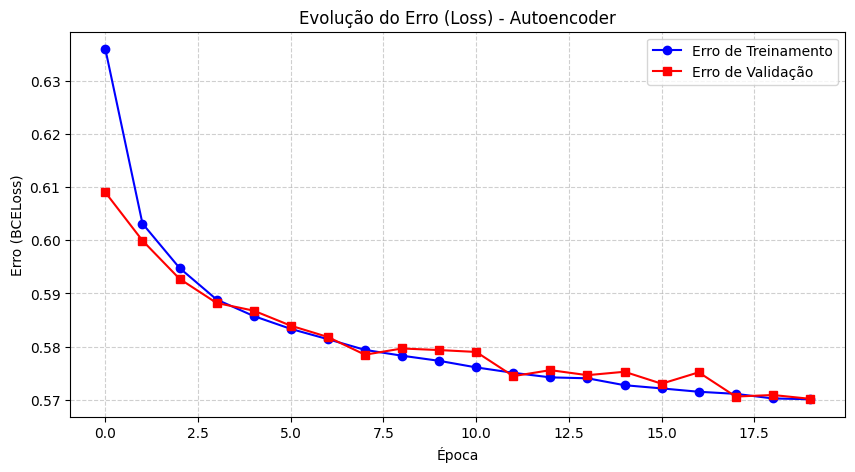

In [ ]:
import matplotlib.pyplot as plt

# Configura o tamanho e o estilo do gráfico
plt.figure(figsize=(10, 5))
plt.plot(historico_loss_train, label='Erro de Treinamento', color='blue', marker='o')
plt.plot(historico_loss_val, label='Erro de Validação', color='red', marker='s')

# Detalhes visuais
plt.title('Evolução do Erro (Loss) - Autoencoder')
plt.xlabel('Época')
plt.ylabel('Erro (BCELoss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Exibe o gráfico
plt.show()

🔍 O que observar no gráfico?

Curvas Descendo: Se ambas as linhas estão caindo e se aproximando do zero, seu Autoencoder está aprendendo a reconstruir as imagens com perfeição.

A "Diferença" (Gap): Se a linha azul (treino) continuar descendo muito e a vermelha (validação) começar a subir ou estabilizar, seu modelo está "decorando" (overfitting).

Estabilidade: Se as curvas ficarem "flat" (planas) antes da época 20, significa que o modelo já aprendeu tudo o que podia e você não precisaria de mais épocas.

## Etapa 5: Geração do encoder

In [ ]:
# 1. model.children():
# Este método retorna um "iterador" sobre todas as camadas principais
# (submódulos) que definimos dentro da classe autoencoder.
# Ele mostra as camadas na ordem em que foram criadas.

# 2. list(...):
# Como o children() é apenas um iterador, nós o transformamos em uma
# LISTA do Python para que possamos acessar as camadas por índice
# ou simplesmente imprimi-las na tela de forma legível.

# O que você verá no seu caso (Autoencoder Linear):
# [Linear(in_features=3072, out_features=1536),
#  Linear(in_features=1536, out_features=768),
#  Linear(in_features=768, out_features=1536),
#  Linear(in_features=1536, out_features=3072),
#  ReLU(),
#  Sigmoid()]

list(model.children())

[Linear(in_features=3072, out_features=1536, bias=True),
 Linear(in_features=1536, out_features=768, bias=True),
 Linear(in_features=768, out_features=1536, bias=True),
 Linear(in_features=1536, out_features=3072, bias=True),
 ReLU(),
 Sigmoid()]

Em vez de criar um novo modelo do zero, estamos extraindo apenas a primeira metade do seu autoencoder (a parte que comprime os dados) para usá-la de forma independente.

In [ ]:
# Criando uma classe específica apenas para a parte da COMPRESSÃO (Encoder)
class encoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Aqui está o "pulo do gato": em vez de definir novas camadas,
        # nós roubamos as camadas que já foram TREINADAS no modelo anterior.

        # Pega a 1ª camada do autoencoder (Linear 3072 -> 1536)
        self.encoder0 = list(model.children())[0]

        # Pega a 2ª camada do autoencoder (Linear 1536 -> 768)
        self.encoder1 = list(model.children())[1]

        # Pega a camada de ativação ReLU que estava na 5ª posição da lista
        self.activation0 = list(model.children())[4]

    def forward(self, X):
        # O fluxo de dados agora só vai até o "gargalo" (espaço latente).
        # Ele recebe a imagem (3072) e entrega apenas o código resumido (768).
        X = self.activation0(self.encoder0(X))
        X = self.activation0(self.encoder1(X))

        # A saída aqui não é mais uma imagem, mas um vetor de características.
        return X

In [ ]:
# 1. model1 = encoder():
# Cria o objeto baseado na classe 'encoder' que acabamos de definir.
# Como essa classe "roubou" as camadas do 'model' original (o autoencoder),
# o 'model1' já nasce "inteligente", contendo todos os pesos que você
# treinou durante as 100 épocas.
model1 = encoder()

# 2. model1.to(device):
# Garante que esse novo modelo resida no mesmo lugar que seus dados.
# Se você for passar uma imagem que está na GPU para ser comprimida,
# o 'model1' precisa estar lá para recebê-la.
model1.to(device)

encoder(
  (encoder0): Linear(in_features=3072, out_features=1536, bias=True)
  (encoder1): Linear(in_features=1536, out_features=768, bias=True)
  (activation0): ReLU()
)

## Etapa 6: Geração do decoder

In [ ]:
# Criando uma classe específica apenas para a parte da RECONSTRUÇÃO (Decoder)
class decoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Assim como fizemos no encoder, aqui nós pegamos as camadas do
        # autoencoder original que cuidam da expansão dos dados.

        # Pega a 3ª camada (Linear 768 -> 1536)
        self.decoder0 = list(model.children())[2]

        # Pega a 4ª camada (Linear 1536 -> 3072) - reconstrói o tamanho original
        self.decoder1 = list(model.children())[3]

        # Pega a ativação ReLU (posição 4) para as camadas intermediárias
        self.activation0 = list(model.children())[4]

        # Pega a ativação Sigmoid (posição 5) para garantir que os pixels
        # reconstruídos fiquem entre 0 e 1.
        self.activation1 = list(model.children())[5]

    def forward(self, X):
        # O fluxo aqui é inverso: entra um vetor compacto de 768 números
        # e o modelo tenta expandi-lo até chegar nos 3072 pixels originais.
        X = self.activation0(self.decoder0(X))
        X = self.activation1(self.decoder1(X))

        # A saída agora volta a ser uma representação de imagem (vetorizada).
        return X

In [ ]:
# 1. model2 = decoder():
# Cria o objeto baseado na classe 'decoder'.
# Ele herda automaticamente os pesos que foram exaustivamente treinados
# no seu autoencoder principal. Agora, o 'model2' é um especialista
# em "descomprimir" informações.
model2 = decoder()

# 2. model2.to(device):
# Move o decoder para a GPU (ou CPU).
# Isso é necessário para que ele possa receber os vetores vindo do
# seu 'encoder' (model1) ou vetores gerados aleatoriamente na GPU.
model2.to(device)

decoder(
  (decoder0): Linear(in_features=768, out_features=1536, bias=True)
  (decoder1): Linear(in_features=1536, out_features=3072, bias=True)
  (activation0): ReLU()
  (activation1): Sigmoid()
)

## Etapa 7: Visualização dos resultados

In [ ]:
numero_imagens = 10

# Imagens originais
imagens_teste = next(iter(loader_val))[0][:numero_imagens]
imagens_teste = imagens_teste.to(device)
# Para passar para o encoder, temos que achatar os dados (a primeira dimensão representa o número de imagens, no caso 10).
imagens_teste = imagens_teste.view(-1, 3072) # batch =1 (de acordo com o treinamento)

In [ ]:
imagens_teste.shape

torch.Size([10, 3072])

In [ ]:
# Imagens codificadas
model1.eval()
imagens_codificadas = model1(imagens_teste)

In [ ]:
imagens_codificadas.shape

torch.Size([10, 768])

In [ ]:
# Imagens decodificadas
model2.eval()
imagens_decodificadas = model2(imagens_codificadas)

In [ ]:
imagens_decodificadas.shape

torch.Size([10, 3072])

In [ ]:
# Formatando as imagens para visualização
# Nesse caso, nós primeiro temos que retornar os dados para o formato original (n_amostras, n_dimensoes, n_pixels horizontal, n_pixels vertical), e depois permutar as dimensões porque o método que vamos usar para visualizar as imagens, `plt.imshow`, pede que as dimensões representando os canais de cor sejam os últimos.
imagens_teste = imagens_teste.view(-1, 3, 32, 32).permute(0, 2, 3, 1).detach().cpu().numpy()
imagens_codificadas = imagens_codificadas.view(-1, 3, 16, 16).permute(0, 2, 3, 1).detach().cpu().numpy()
imagens_decodificadas = imagens_decodificadas.view(-1, 3, 32, 32).permute(0, 2, 3, 1).detach().cpu().numpy().reshape(-1, 32, 32, 3)

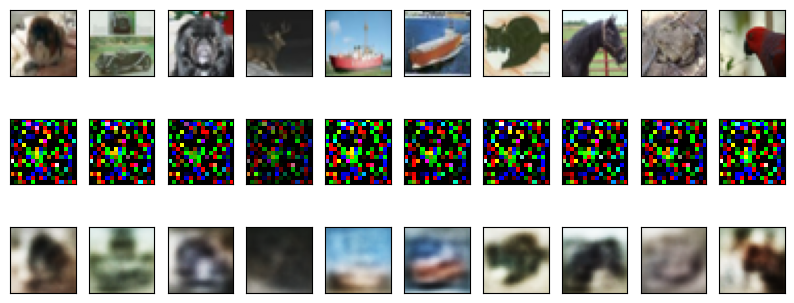

In [ ]:
fig, axes = plt.subplots(nrows = 3, ncols = numero_imagens, figsize = (10, 4))
for imagens, ax_row in zip([imagens_teste, imagens_codificadas, imagens_decodificadas], axes):
    for img, ax in zip(imagens, ax_row):
        ax.imshow(img, cmap = 'gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)